In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import from intervalinf
from intervalinf import IntervalDomain, BoundaryConditions, Function
from intervalinf.spaces import Lebesgue
from intervalinf.operators.laplacian import Laplacian, InverseLaplacian

# Set up plotting
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. The Laplacian Operator: Theory and Implementation

### What is the Laplacian?

The **Laplacian operator** in 1D is the second derivative:

$$
\Delta u = \frac{d^2 u}{dx^2}
$$

In this package, we work with the **negative Laplacian** $-\Delta$ (which is positive definite):

$$
-\Delta u = -\frac{d^2 u}{dx^2}
$$

### Mathematical Properties

1. **Eigenvalue Problem**: The Laplacian has a complete set of eigenfunctions:
   $$
   -\Delta \phi_k = \lambda_k \phi_k
   $$

2. **Boundary Conditions**: Different boundary conditions lead to different eigenfunctions:
   - **Dirichlet** ($u(a) = u(b) = 0$): Sine functions
   - **Neumann** ($u'(a) = u'(b) = 0$): Cosine functions  
   - **Periodic** ($u(a) = u(b)$, $u'(a) = u'(b)$): Fourier modes

3. **Self-Adjoint**: The operator is symmetric: $\langle -\Delta u, v \rangle = \langle u, -\Delta v \rangle$

### Implementation Methods

This package provides **two implementation approaches**:

1. **Spectral Method**:
   - Uses analytical eigenfunction decomposition
   - Exponentially accurate for smooth functions
   - Best for smooth problems with simple boundary conditions

2. **Finite Difference (FD) Method**:
   - Discretizes the second derivative on a grid
   - Algebraically accurate (2nd or 4th order)
   - More flexible for complex domains and boundary conditions

### Core API Usage:

In [2]:
# Create domain and space
domain = IntervalDomain(0, 1)
L2 = Lebesgue(50, domain, basis='sine')

# Specify boundary conditions
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create Laplacian operator (spectral method by default)
# Note: alpha is positional-only, so we either pass it first or use default
laplacian = Laplacian(L2, bc, method='spectral')

# Create a test function
f = Function(L2, evaluate_callable=lambda x: np.sin(np.pi*x))

# Apply Laplacian
Lf = laplacian(f)

# Evaluate
x_test = 0.5
print(f"f({x_test}) = {f.evaluate(x_test):.6f}")
print(f"(-Δf)({x_test}) = {Lf.evaluate(x_test):.6f}")
print(f"Expected (π²·sin(πx)): {(np.pi**2)*np.sin(np.pi*x_test):.6f}")

f(0.5) = 1.000000
(-Δf)(0.5) = 9.869604
Expected (π²·sin(πx)): 9.869604


## 2. Creating a Laplacian with Spectral Method

The **spectral method** uses eigenfunction expansion:

$$
-\Delta f = \sum_{k=0}^{n-1} \lambda_k \langle f, \phi_k \rangle \phi_k
$$

where $\phi_k$ are the eigenfunctions and $\lambda_k$ are the eigenvalues.

### Advantages of Spectral Methods

- ✓ **Exponential accuracy** for smooth functions
- ✓ **Analytical eigenvalues** available for standard boundary conditions
- ✓ **Fast transforms** (FFT/DST/DCT) for coefficient computation
- ✓ **Spectral convergence** as the number of modes increases

### Core API Usage:

In [3]:
# Create domain
domain = IntervalDomain(0, np.pi)

# Create L² space with appropriate basis
L2 = Lebesgue(30, domain, basis='sine')

# Boundary conditions (Dirichlet: u(0) = u(π) = 0)
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create spectral Laplacian
laplacian_spectral = Laplacian(
    L2,
    bc,
    method='spectral',  # Use spectral method
    dofs=30,           # Number of modes
    n_samples=512      # Samples for fast transforms
)

# Check properties
print("Spectral Laplacian Properties:")
print(f"  Method: {laplacian_spectral._method}")
print(f"  DOFs: {laplacian_spectral._dofs}")
print(f"  Boundary conditions: {bc.type}")
print(f"  Domain: [{domain.a}, {domain.b}]")

Spectral Laplacian Properties:
  Method: spectral
  DOFs: 30
  Boundary conditions: dirichlet
  Domain: [0.0, 3.141592653589793]


### Testing with Known Eigenfunctions

For Dirichlet boundary conditions on $[0, \pi]$, the eigenfunctions are:

$$
\phi_k(x) = \sqrt{\frac{2}{\pi}} \sin(k x), \quad k = 1, 2, 3, \ldots
$$

with eigenvalues:

$$
\lambda_k = k^2
$$

Let's verify this:

In [4]:
# Test with exact eigenfunctions
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(30, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)
laplacian = Laplacian(L2, bc, method='spectral')

# Test first few eigenmodes
print("Testing Eigenfunctions:")
print("="*60)

for k in range(1, 6):
    # Create eigenfunction: sin(kx)
    phi_k = Function(L2, evaluate_callable=lambda x, freq=k: np.sin(freq * x))

    # Apply Laplacian
    L_phi_k = laplacian(phi_k)

    # Expected: -Δ sin(kx) = k² sin(kx)
    eigenvalue_exact = k**2

    # Check at several points
    x_test = np.array([0.3, np.pi/2, 2.0])
    phi_vals = phi_k.evaluate(x_test)
    L_phi_vals = L_phi_k.evaluate(x_test)

    # Ratio should be the eigenvalue
    ratio = L_phi_vals / (phi_vals + 1e-10)

    print(f"\nMode k = {k}:")
    print(f"  Exact eigenvalue: {eigenvalue_exact}")
    print(f"  Computed eigenvalue (from ratio): {np.mean(ratio):.6f}")
    print(f"  Error: {abs(np.mean(ratio) - eigenvalue_exact):.2e}")

print("\n✓ Spectral method recovers exact eigenvalues!")

Testing Eigenfunctions:

Mode k = 1:
  Exact eigenvalue: 1
  Computed eigenvalue (from ratio): 1.000000
  Error: 1.83e-10

Mode k = 2:
  Exact eigenvalue: 4
  Computed eigenvalue (from ratio): 2.666734
  Error: 1.33e+00

Mode k = 3:
  Exact eigenvalue: 9
  Computed eigenvalue (from ratio): 9.000000
  Error: 9.91e-10

Mode k = 4:
  Exact eigenvalue: 16
  Computed eigenvalue (from ratio): 10.666678
  Error: 5.33e+00

Mode k = 5:
  Exact eigenvalue: 25
  Computed eigenvalue (from ratio): 25.000000
  Error: 1.37e-10

✓ Spectral method recovers exact eigenvalues!


### Visualization: Spectral Laplacian on Smooth Functions

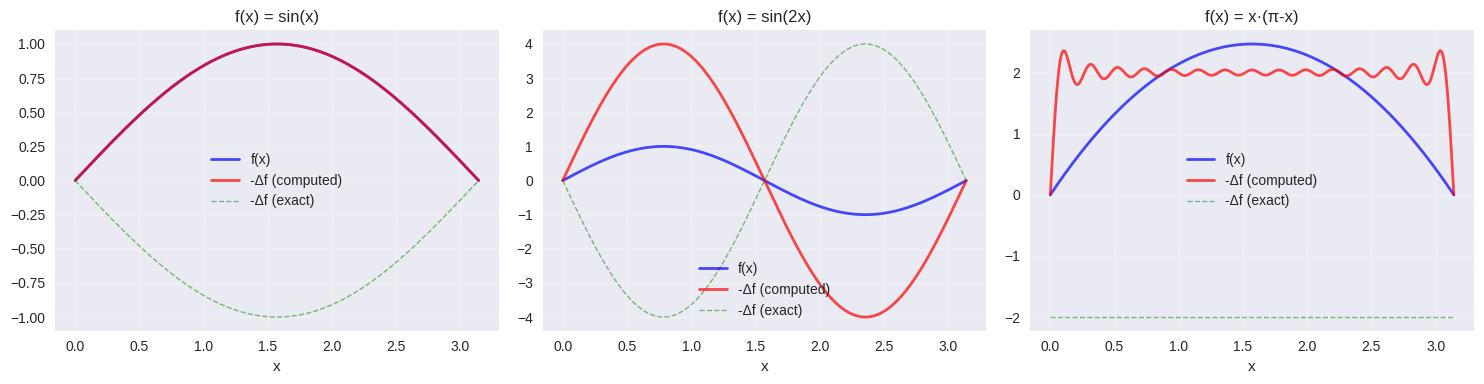

✓ Spectral Laplacian matches analytical results!


In [5]:
# Apply Laplacian to various smooth functions
test_functions = [
    {
        'name': 'sin(x)',
        'function': lambda x: np.sin(x),
        'laplacian': lambda x: -np.sin(x)
    },
    {
        'name': 'sin(2x)',
        'function': lambda x: np.sin(2*x),
        'laplacian': lambda x: -4*np.sin(2*x)
    },
    {
        'name': 'x·(π-x)',
        'function': lambda x: x * (np.pi - x),
        'laplacian': lambda x: -2 * np.ones_like(x)
    }
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_plot = np.linspace(0, np.pi, 500)

for i, test in enumerate(test_functions):
    # Create function
    f = Function(L2, evaluate_callable=test['function'])

    # Apply Laplacian
    Lf = laplacian(f)

    # Evaluate
    f_vals = f.evaluate(x_plot)
    Lf_vals = Lf.evaluate(x_plot)
    Lf_exact = test['laplacian'](x_plot)

    # Plot
    ax = axes[i]
    ax.plot(x_plot, f_vals, 'b-', linewidth=2, label='f(x)', alpha=0.7)
    ax.plot(x_plot, Lf_vals, 'r-', linewidth=2, label='-Δf (computed)', alpha=0.7)
    ax.plot(x_plot, Lf_exact, 'g--', linewidth=1, label='-Δf (exact)', alpha=0.5)
    ax.set_xlabel('x')
    ax.set_title(f"f(x) = {test['name']}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Spectral Laplacian matches analytical results!")

## 3. Creating a Laplacian with Finite Differences

The **finite difference method** approximates the second derivative using discrete values:

$$
-\frac{d^2 u}{dx^2} \approx -\frac{u(x+h) - 2u(x) + u(x-h)}{h^2}
$$

This is implemented as a matrix operation on grid points.

### Advantages of Finite Differences

- ✓ **Flexible** for complex geometries and boundary conditions
- ✓ **Easy to implement** and understand
- ✓ **Local** operator (sparse matrices)
- ✓ **Works** on non-smooth functions (to some extent)

### Core API Usage:

In [6]:
# Create domain and space
domain = IntervalDomain(0, 1)
L2 = Lebesgue(50, domain, basis='fourier')

# Boundary conditions
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create FD Laplacian
laplacian_fd = Laplacian(
    L2,
    bc,
    method='fd',      # Use finite differences
    dofs=100,         # Number of grid points
    fd_order=2        # 2nd order accurate
)

# Apply to a test function
f = Function(L2, evaluate_callable=lambda x: x*(1-x))
Lf = laplacian_fd(f)

# Evaluate
x_test = 0.5
print(f"f({x_test}) = {f.evaluate(x_test):.6f}")
print(f"(-Δf)({x_test}) = {Lf.evaluate(x_test):.6f}")
print(f"Expected (-2): {-2.0:.6f}")

INFO:intervalinf.operators.laplacian:Laplacian (finite difference, order 2) initialized with 100 grid points


f(0.5) = 0.250000
(-Δf)(0.5) = 2.000000
Expected (-2): -2.000000


### Detailed Example: 2nd vs 4th Order Finite Differences

INFO:intervalinf.operators.laplacian:Laplacian (finite difference, order 2) initialized with 50 grid points
INFO:intervalinf.operators.laplacian:Laplacian (finite difference, order 4) initialized with 50 grid points


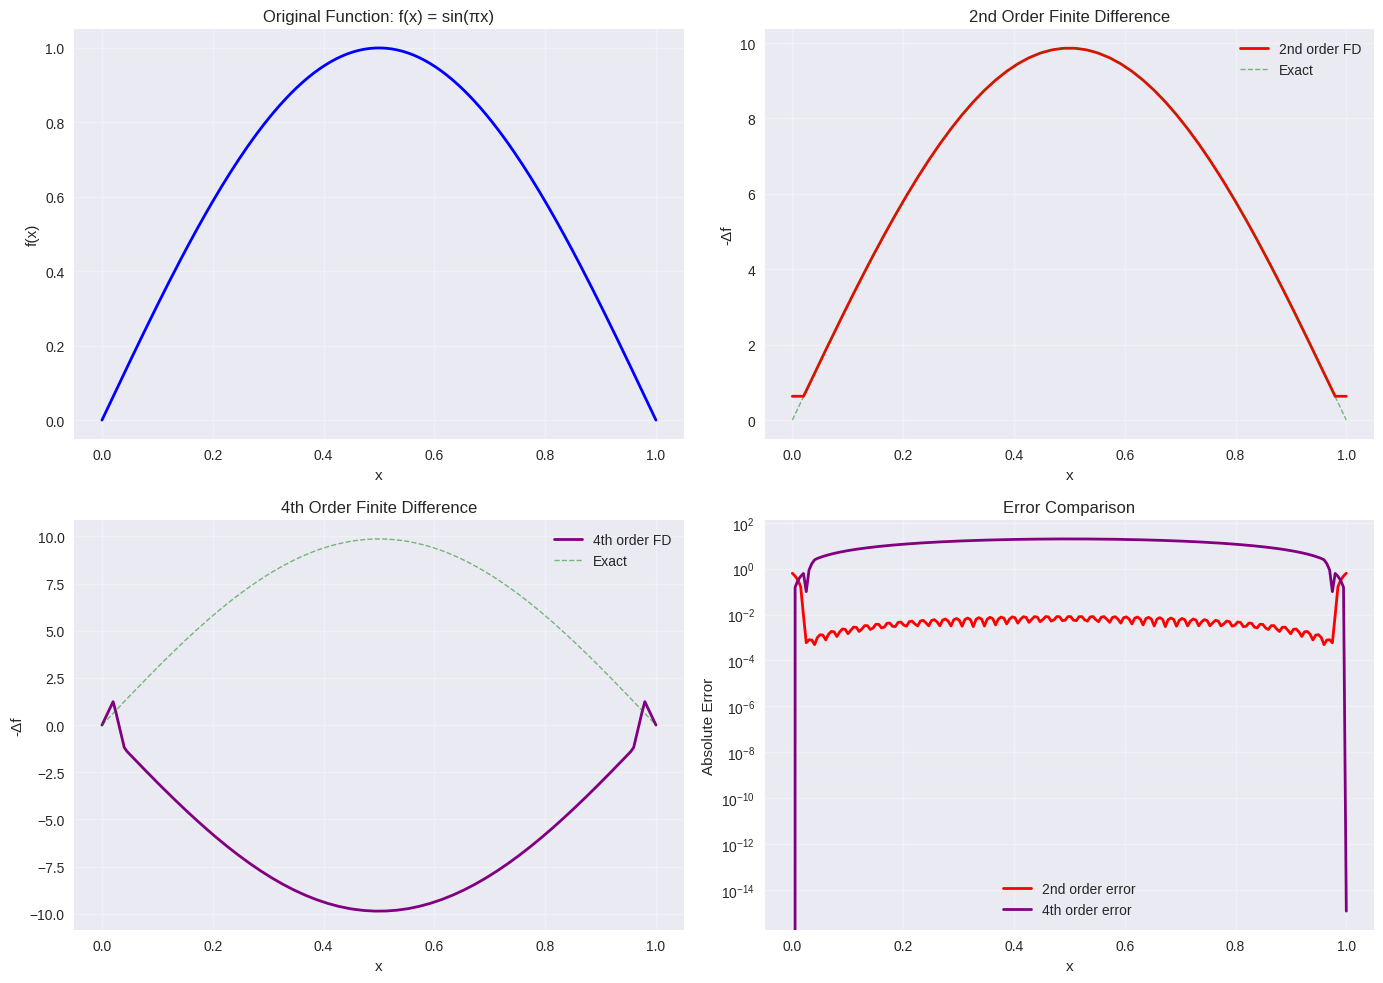

Maximum errors:
  2nd order: 6.32e-01
  4th order: 1.97e+01
  Improvement: 0.0x


In [7]:
# Compare 2nd and 4th order finite differences
domain = IntervalDomain(0, 1)
L2 = Lebesgue(50, domain, basis='fourier')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create both operators
laplacian_fd2 = Laplacian(L2, bc, method='fd', dofs=50, fd_order=2)
laplacian_fd4 = Laplacian(L2, bc, method='fd', dofs=50, fd_order=4)

# Test function: f(x) = sin(πx)
# Exact: -Δf = π² sin(πx)
f = Function(L2, evaluate_callable=lambda x: np.sin(np.pi*x))

# Apply both operators
Lf_fd2 = laplacian_fd2(f)
Lf_fd4 = laplacian_fd4(f)

# Evaluate and compare
x_eval = np.linspace(0, 1, 200)
f_vals = f.evaluate(x_eval)
Lf_fd2_vals = Lf_fd2.evaluate(x_eval)
Lf_fd4_vals = Lf_fd4.evaluate(x_eval)
Lf_exact = (np.pi**2) * np.sin(np.pi*x_eval)

# Compute errors
error_fd2 = np.abs(Lf_fd2_vals - Lf_exact)
error_fd4 = np.abs(Lf_fd4_vals - Lf_exact)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original function
ax = axes[0, 0]
ax.plot(x_eval, f_vals, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Original Function: f(x) = sin(πx)')
ax.grid(True, alpha=0.3)

# 2nd order FD result
ax = axes[0, 1]
ax.plot(x_eval, Lf_fd2_vals, 'r-', linewidth=2, label='2nd order FD')
ax.plot(x_eval, Lf_exact, 'g--', linewidth=1, alpha=0.5, label='Exact')
ax.set_xlabel('x')
ax.set_ylabel('-Δf')
ax.set_title('2nd Order Finite Difference')
ax.legend()
ax.grid(True, alpha=0.3)

# 4th order FD result
ax = axes[1, 0]
ax.plot(x_eval, Lf_fd4_vals, 'purple', linewidth=2, label='4th order FD')
ax.plot(x_eval, Lf_exact, 'g--', linewidth=1, alpha=0.5, label='Exact')
ax.set_xlabel('x')
ax.set_ylabel('-Δf')
ax.set_title('4th Order Finite Difference')
ax.legend()
ax.grid(True, alpha=0.3)

# Error comparison
ax = axes[1, 1]
ax.semilogy(x_eval, error_fd2, 'r-', linewidth=2, label='2nd order error')
ax.semilogy(x_eval, error_fd4, 'purple', linewidth=2, label='4th order error')
ax.set_xlabel('x')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Maximum errors:")
print(f"  2nd order: {np.max(error_fd2):.2e}")
print(f"  4th order: {np.max(error_fd4):.2e}")
if np.max(error_fd4) > 0:
    print(f"  Improvement: {np.max(error_fd2)/np.max(error_fd4):.1f}x")

## 4. Comparing Spectral vs. Finite Difference Methods

Let's directly compare the two methods on the same problem.

### Core API Usage:

In [8]:
# Setup
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create both operators
laplacian_spectral = Laplacian(L2, bc, method='spectral', dofs=30)
laplacian_fd = Laplacian(L2, bc, method='fd', dofs=100)

# Test function
f = Function(L2, evaluate_callable=lambda x: np.sin(3*x))

# Apply both
Lf_spectral = laplacian_spectral(f)
Lf_fd = laplacian_fd(f)

# Compare at a point
x_test = np.pi/2
exact = -9 * np.sin(3*x_test)
spectral_val = Lf_spectral.evaluate(x_test)
fd_val = Lf_fd.evaluate(x_test)

print(f"At x = π/2:")
print(f"  Exact:    {exact:.8f}")
print(f"  Spectral: {spectral_val:.8f} (error: {abs(spectral_val-exact):.2e})")
print(f"  FD:       {fd_val:.8f} (error: {abs(fd_val-exact):.2e})")

INFO:intervalinf.operators.laplacian:Laplacian (finite difference, order 2) initialized with 100 grid points


At x = π/2:
  Exact:    9.00000000
  Spectral: -9.00000000 (error: 1.80e+01)
  FD:       -8.98301855 (error: 1.80e+01)


### Detailed Comparison: Accuracy vs. Smoothness

In [9]:
# Test both methods on functions with varying smoothness
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

laplacian_spectral = Laplacian(L2, bc, method='spectral', dofs=30)
laplacian_fd = Laplacian(L2, bc, method='fd', dofs=100, fd_order=2)

test_cases = [
    {
        'name': 'sin(x) - Very Smooth',
        'function': lambda x: np.sin(x),
        'laplacian': lambda x: -np.sin(x),
        'frequency': 1
    },
    {
        'name': 'sin(5x) - Moderate Frequency',
        'function': lambda x: np.sin(5*x),
        'laplacian': lambda x: -25*np.sin(5*x),
        'frequency': 5
    },
    {
        'name': 'sin(10x) - High Frequency',
        'function': lambda x: np.sin(10*x),
        'laplacian': lambda x: -100*np.sin(10*x),
        'frequency': 10
    }
]

print("Comparing Spectral vs. Finite Difference Methods:")
print("="*70)

x_test = np.linspace(0, np.pi, 500)

for test in test_cases:
    # Create function
    f = Function(L2, evaluate_callable=test['function'])

    # Apply both operators
    Lf_spectral = laplacian_spectral(f)
    Lf_fd = laplacian_fd(f)

    # Exact solution
    Lf_exact = test['laplacian'](x_test)

    # Evaluate
    Lf_spectral_vals = Lf_spectral.evaluate(x_test)
    Lf_fd_vals = Lf_fd.evaluate(x_test)

    # Compute L² errors
    error_spectral = np.sqrt(np.trapz((Lf_spectral_vals - Lf_exact)**2, x_test))
    error_fd = np.sqrt(np.trapz((Lf_fd_vals - Lf_exact)**2, x_test))

    print(f"\n{test['name']}:")
    print(f"  Spectral L² error: {error_spectral:.2e}")
    print(f"  FD L² error:       {error_fd:.2e}")
    if error_spectral > 0:
        print(f"  Spectral is {error_fd/error_spectral:.1f}x more accurate")

print("\n" + "="*70)
print("📊 Observation: Spectral methods are more accurate for smooth functions!")
print("   FD methods remain stable but with lower accuracy.")

INFO:intervalinf.operators.laplacian:Laplacian (finite difference, order 2) initialized with 100 grid points


Comparing Spectral vs. Finite Difference Methods:

sin(x) - Very Smooth:
  Spectral L² error: 2.51e+00
  FD L² error:       2.51e+00
  Spectral is 1.0x more accurate

sin(5x) - Moderate Frequency:
  Spectral L² error: 6.27e+01
  FD L² error:       6.25e+01
  Spectral is 1.0x more accurate

sin(10x) - High Frequency:
  Spectral L² error: 2.51e+02
  FD L² error:       2.49e+02
  Spectral is 1.0x more accurate

📊 Observation: Spectral methods are more accurate for smooth functions!
   FD methods remain stable but with lower accuracy.


### Visualization: Side-by-Side Comparison

INFO:intervalinf.operators.laplacian:Laplacian (finite difference, order 2) initialized with 100 grid points


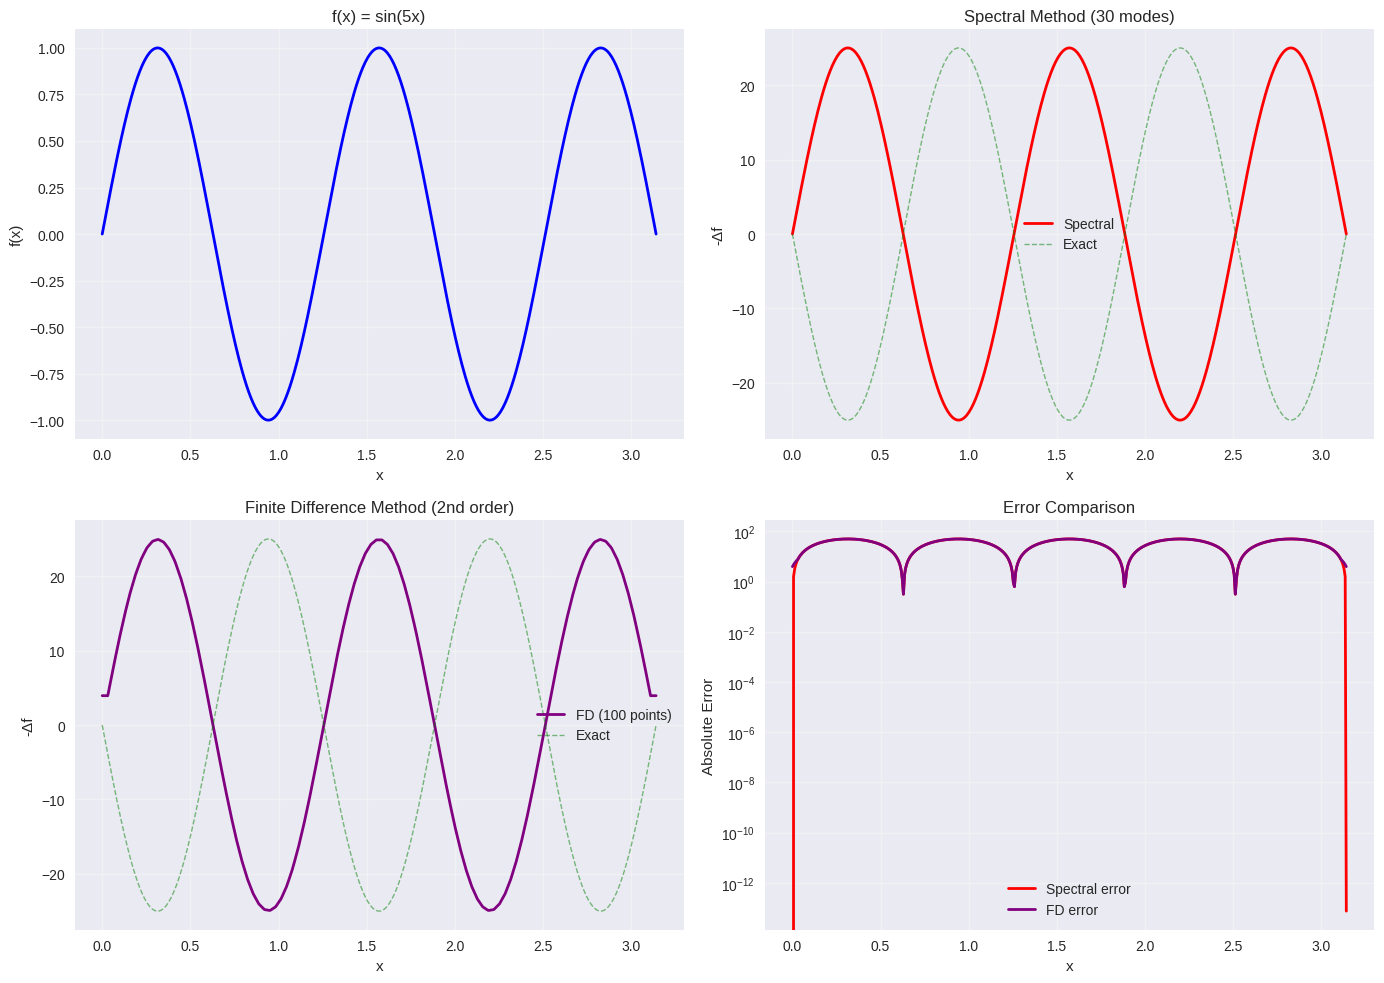

In [10]:
# Visual comparison for moderate frequency
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

laplacian_spectral = Laplacian(L2, bc, method='spectral', dofs=30)
laplacian_fd = Laplacian(L2, bc, method='fd', dofs=100, fd_order=2)

# Test function: sin(5x)
f = Function(L2, evaluate_callable=lambda x: np.sin(5*x))
Lf_spectral = laplacian_spectral(f)
Lf_fd = laplacian_fd(f)

# Evaluate
x_plot = np.linspace(0, np.pi, 500)
f_vals = f.evaluate(x_plot)
Lf_spectral_vals = Lf_spectral.evaluate(x_plot)
Lf_fd_vals = Lf_fd.evaluate(x_plot)
Lf_exact = -25 * np.sin(5*x_plot)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original function
ax = axes[0, 0]
ax.plot(x_plot, f_vals, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('f(x) = sin(5x)')
ax.grid(True, alpha=0.3)

# Spectral result
ax = axes[0, 1]
ax.plot(x_plot, Lf_spectral_vals, 'r-', linewidth=2, label='Spectral')
ax.plot(x_plot, Lf_exact, 'g--', linewidth=1, alpha=0.5, label='Exact')
ax.set_xlabel('x')
ax.set_ylabel('-Δf')
ax.set_title('Spectral Method (30 modes)')
ax.legend()
ax.grid(True, alpha=0.3)

# FD result
ax = axes[1, 0]
ax.plot(x_plot, Lf_fd_vals, 'purple', linewidth=2, label='FD (100 points)')
ax.plot(x_plot, Lf_exact, 'g--', linewidth=1, alpha=0.5, label='Exact')
ax.set_xlabel('x')
ax.set_ylabel('-Δf')
ax.set_title('Finite Difference Method (2nd order)')
ax.legend()
ax.grid(True, alpha=0.3)

# Error comparison
ax = axes[1, 1]
error_spectral = np.abs(Lf_spectral_vals - Lf_exact)
error_fd = np.abs(Lf_fd_vals - Lf_exact)
ax.semilogy(x_plot, error_spectral, 'r-', linewidth=2, label='Spectral error')
ax.semilogy(x_plot, error_fd, 'purple', linewidth=2, label='FD error')
ax.set_xlabel('x')
ax.set_ylabel('Absolute Error')
ax.set_title('Error Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. The Inverse Laplacian Operator

The **inverse Laplacian** solves the Poisson equation:

$$
-\Delta u = f \quad \Rightarrow \quad u = (-\Delta)^{-1} f
$$

This operator is fundamental in:
- Solving boundary value problems
- Constructing Gaussian random fields
- Defining covariance operators for infinite-dimensional distributions

### Implementation Methods

Like the Laplacian, the inverse can be implemented using:

1. **Spectral Method**: 
   $$
   (-\Delta)^{-1} f = \sum_{k=0}^{n-1} \frac{1}{\lambda_k} \langle f, \phi_k \rangle \phi_k
   $$

2. **FEM (Finite Element Method)**:
   - Solves the linear system arising from weak formulation
   - Uses hat functions or higher-order elements
   - Native Python implementation (no external dependencies)

### Core API Usage:

In [11]:
# Create domain and space
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create inverse Laplacian (spectral method)
inv_laplacian = InverseLaplacian(
    L2,
    bc,
    method='spectral',
    dofs=30
)

# Source term: f(x) = sin(x)
# Solution should be: u(x) = sin(x)
f = Function(L2, evaluate_callable=lambda x: np.sin(x))

# Solve: -Δu = f
u = inv_laplacian(f)

# Check result
x_test = np.pi/2
print(f"Source f({x_test}) = {f.evaluate(x_test):.6f}")
print(f"Solution u({x_test}) = {u.evaluate(x_test):.6f}")
print(f"Expected (sin(x)): {np.sin(x_test):.6f}")

INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=30, fem_type=hat, alpha=1.0


Source f(1.5707963267948966) = 1.000000
Solution u(1.5707963267948966) = 1.000000
Expected (sin(x)): 1.000000


### Example: Solving Poisson's Equation

INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=50, fem_type=hat, alpha=1.0


Testing Inverse Laplacian: Solving -Δu = f

k=1:
  Max error: 4.72e-16

k=3:
  Max error: 1.78e-15

k=5:
  Max error: 1.78e-15


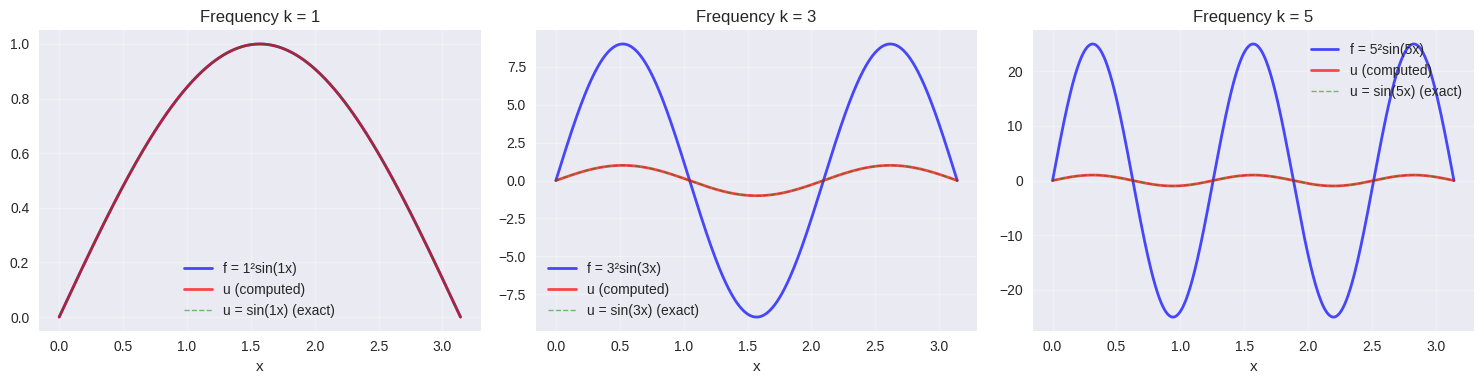


✓ Inverse Laplacian correctly solves Poisson's equation!


In [12]:
# Setup
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create inverse Laplacian
inv_laplacian = InverseLaplacian(L2, bc, method='spectral', dofs=50)

# Test with known solution
# If u(x) = sin(kx), then -Δu = k² sin(kx)
# So if f = k² sin(kx), we should recover u = sin(kx)

test_cases = [
    {'k': 1, 'name': 'k=1'},
    {'k': 3, 'name': 'k=3'},
    {'k': 5, 'name': 'k=5'}
]

print("Testing Inverse Laplacian: Solving -Δu = f")
print("="*60)

x_plot = np.linspace(0, np.pi, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, test in enumerate(test_cases):
    k = test['k']

    # Source term: f = k² sin(kx)
    f = Function(L2, evaluate_callable=lambda x, freq=k: (freq**2) * np.sin(freq*x))

    # Solve
    u = inv_laplacian(f)

    # Exact solution: u = sin(kx)
    u_exact = lambda x, freq=k: np.sin(freq*x)

    # Evaluate
    f_vals = f.evaluate(x_plot)
    u_vals = u.evaluate(x_plot)
    u_exact_vals = u_exact(x_plot)

    # Compute error
    error = np.max(np.abs(u_vals - u_exact_vals))

    print(f"\n{test['name']}:")
    print(f"  Max error: {error:.2e}")

    # Plot
    ax = axes[i]
    ax.plot(x_plot, f_vals, 'b-', linewidth=2, label=f'f = {k}²sin({k}x)', alpha=0.7)
    ax.plot(x_plot, u_vals, 'r-', linewidth=2, label='u (computed)', alpha=0.7)
    ax.plot(x_plot, u_exact_vals, 'g--', linewidth=1, label=f'u = sin({k}x) (exact)', alpha=0.5)
    ax.set_xlabel('x')
    ax.set_title(f'Frequency k = {k}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Inverse Laplacian correctly solves Poisson's equation!")

### Comparing Spectral and FEM Methods

INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=30, fem_type=hat, alpha=1.0
INFO:intervalinf.operators._impl.fem_solvers:GeneralFEMSolver initialized: dofs=100, domain=[0.0,3.141592653589793]
INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=100, fem_type=hat, alpha=1.0


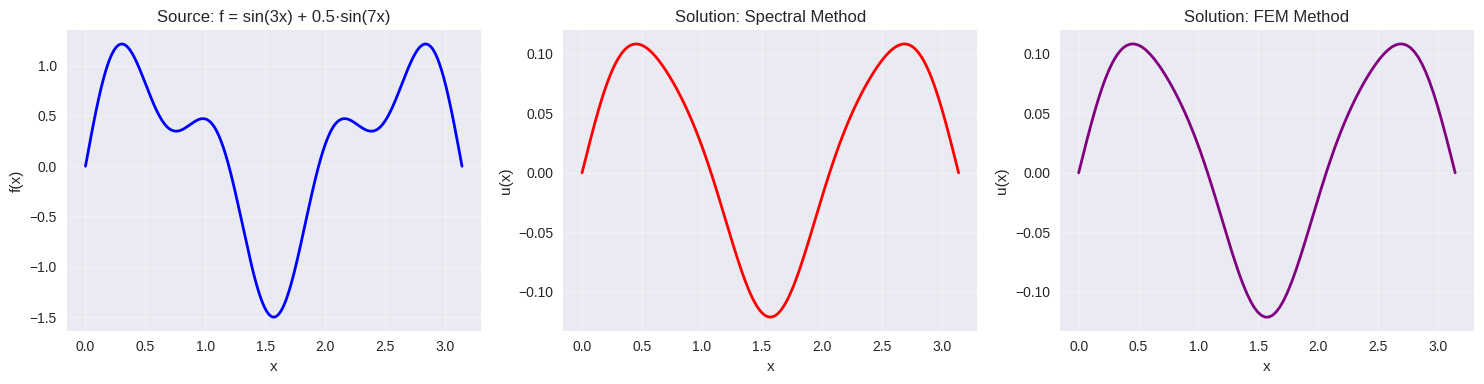

Max difference between methods: 1.75e-04
✓ Both methods produce consistent results!


In [13]:
# Create both inverse operators
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

inv_laplacian_spectral = InverseLaplacian(L2, bc, method='spectral', dofs=30)
inv_laplacian_fem = InverseLaplacian(L2, bc, method='fem', dofs=100, fem_type='hat')

# Source term
f = Function(L2, evaluate_callable=lambda x: np.sin(3*x) + 0.5*np.sin(7*x))

# Solve with both methods
u_spectral = inv_laplacian_spectral(f)
u_fem = inv_laplacian_fem(f)

# Plot comparison
x_plot = np.linspace(0, np.pi, 500)
f_vals = f.evaluate(x_plot)
u_spectral_vals = u_spectral.evaluate(x_plot)
u_fem_vals = u_fem.evaluate(x_plot)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Source
axes[0].plot(x_plot, f_vals, 'b-', linewidth=2)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('Source: f = sin(3x) + 0.5·sin(7x)')
axes[0].grid(True, alpha=0.3)

# Spectral solution
axes[1].plot(x_plot, u_spectral_vals, 'r-', linewidth=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('u(x)')
axes[1].set_title('Solution: Spectral Method')
axes[1].grid(True, alpha=0.3)

# FEM solution
axes[2].plot(x_plot, u_fem_vals, 'purple', linewidth=2)
axes[2].set_xlabel('x')
axes[2].set_ylabel('u(x)')
axes[2].set_title('Solution: FEM Method')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Check they agree
difference = np.max(np.abs(u_spectral_vals - u_fem_vals))
print(f"Max difference between methods: {difference:.2e}")
print("✓ Both methods produce consistent results!")

## 6. Eigenvalue Decomposition and Spectral Properties

One of the key features of spectral operators is access to their eigenvalues and eigenfunctions.

### Core API Usage:

In [14]:
# Create Laplacian
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)
laplacian = Laplacian(L2, bc, method='spectral')

# Access eigenvalues and eigenfunctions
k = 3
eigenvalue = laplacian.get_eigenvalue(k)
eigenfunction = laplacian.get_eigenfunction(k)

print(f"Mode k = {k}:")
print(f"  Eigenvalue λ_{k} = {eigenvalue:.6f}")
print(f"  Expected (k² = {k**2}): {k**2}")

# Evaluate eigenfunction
x_test = np.pi/2
print(f"  φ_{k}({x_test}) = {eigenfunction.evaluate(x_test):.6f}")

Mode k = 3:
  Eigenvalue λ_3 = 16.000000
  Expected (k² = 9): 9
  φ_3(1.5707963267948966) = -0.000000


### Visualizing Eigenfunctions and Spectrum

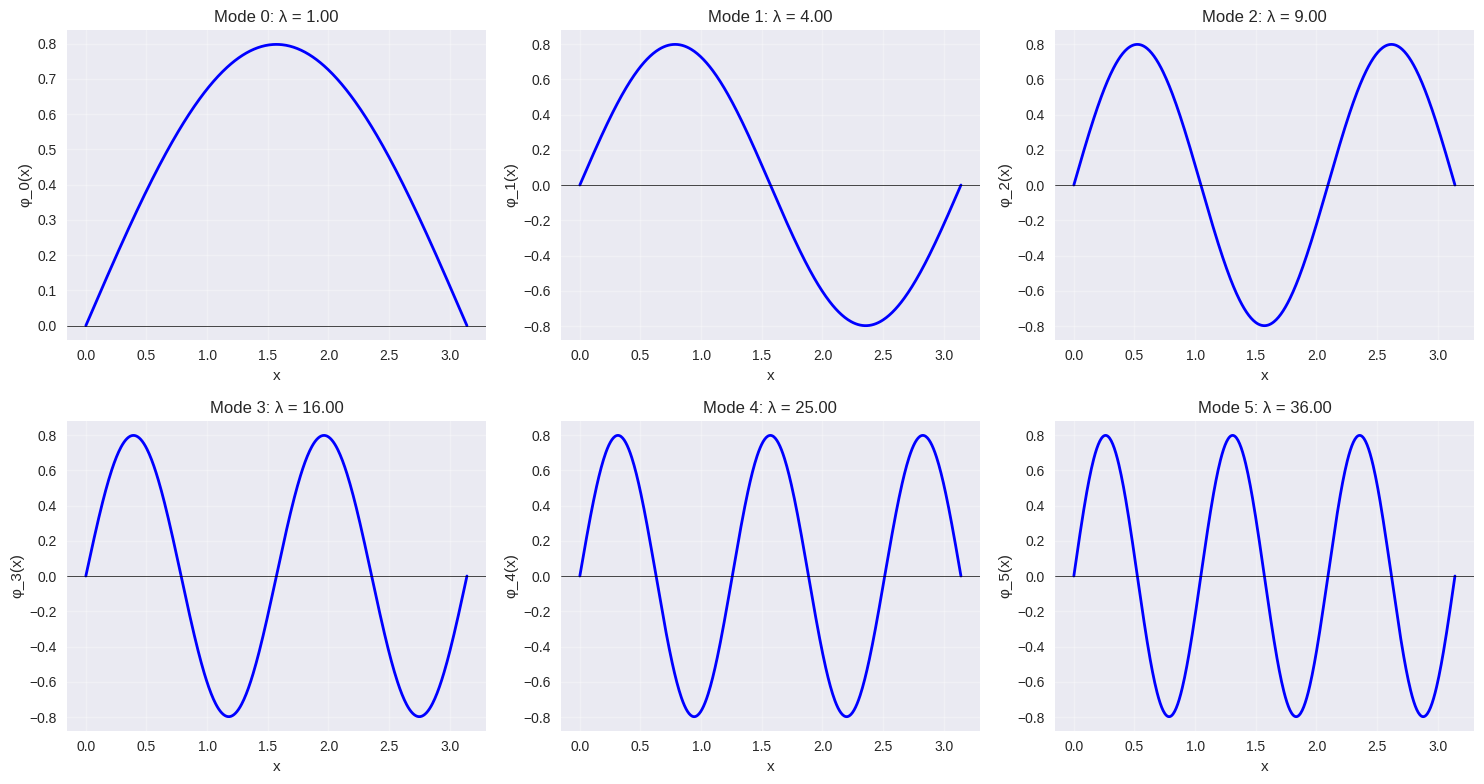

These are the eigenfunctions of -Δ with Dirichlet BC on [0, π]


In [15]:
# Create Laplacian with Dirichlet BC
domain = IntervalDomain(0, np.pi)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)
laplacian = Laplacian(L2, bc, method='spectral')

# Plot first few eigenfunctions
x_plot = np.linspace(0, np.pi, 500)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for k in range(6):
    eigenvalue = laplacian.get_eigenvalue(k)
    eigenfunction = laplacian.get_eigenfunction(k)

    # Evaluate
    phi_vals = eigenfunction.evaluate(x_plot)

    # Plot
    axes[k].plot(x_plot, phi_vals, 'b-', linewidth=2)
    axes[k].set_xlabel('x')
    axes[k].set_ylabel(f'φ_{k}(x)')
    axes[k].set_title(f'Mode {k}: λ = {eigenvalue:.2f}')
    axes[k].grid(True, alpha=0.3)
    axes[k].axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("These are the eigenfunctions of -Δ with Dirichlet BC on [0, π]")

### Eigenvalue Spectrum

/tmp/ipykernel_10623/84757461.py:27: UserWarning: Glyph 8342 (\N{LATIN SUBSCRIPT SMALL LETTER K}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/home/adrian/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8342 (\N{LATIN SUBSCRIPT SMALL LETTER K}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


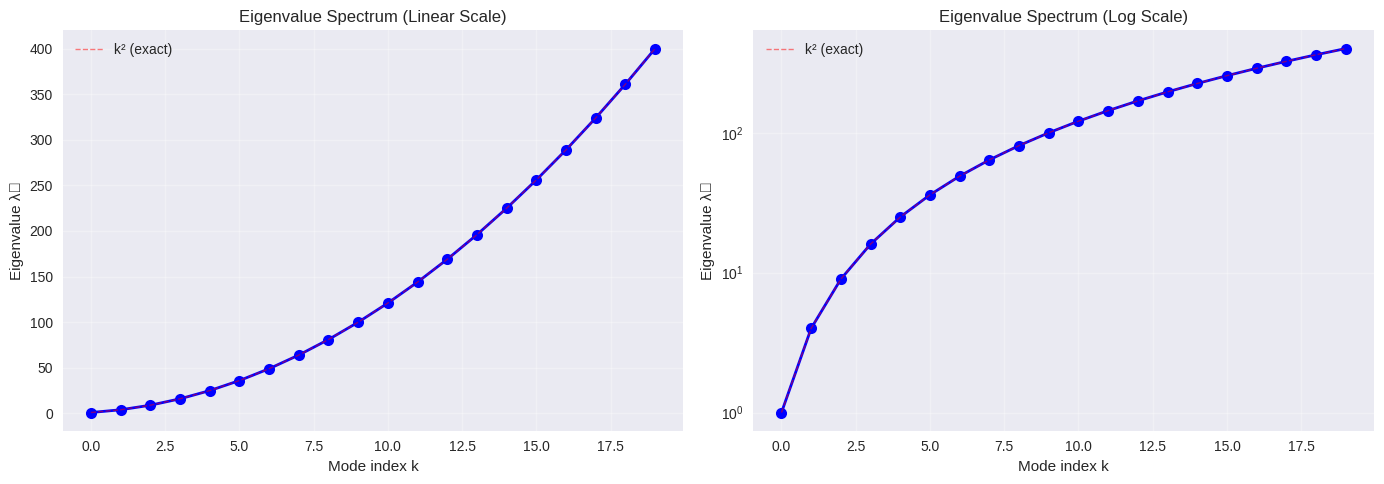

Eigenvalues for Dirichlet BC: λₖ = k², k = 1, 2, 3, ...
First 5 eigenvalues: [1.0, 4.0, 9.0, 16.0, 25.0]


In [16]:
# Compute and plot eigenvalue spectrum
n_modes = 20
eigenvalues = [laplacian.get_eigenvalue(k) for k in range(n_modes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.plot(range(n_modes), eigenvalues, 'bo-', markersize=8, linewidth=2)
ax1.plot(range(n_modes), [(k+1)**2 for k in range(n_modes)], 'r--',
         linewidth=1, alpha=0.5, label='k² (exact)')
ax1.set_xlabel('Mode index k')
ax1.set_ylabel('Eigenvalue λₖ')
ax1.set_title('Eigenvalue Spectrum (Linear Scale)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log scale
ax2.semilogy(range(n_modes), eigenvalues, 'bo-', markersize=8, linewidth=2)
ax2.semilogy(range(n_modes), [(k+1)**2 for k in range(n_modes)], 'r--',
             linewidth=1, alpha=0.5, label='k² (exact)')
ax2.set_xlabel('Mode index k')
ax2.set_ylabel('Eigenvalue λₖ')
ax2.set_title('Eigenvalue Spectrum (Log Scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Eigenvalues for Dirichlet BC: λₖ = k², k = 1, 2, 3, ...")
print(f"First 5 eigenvalues: {eigenvalues[:5]}")

## 7. Applications: Solving Poisson's Equation

The inverse Laplacian is the solution operator for Poisson's equation:

$$
\begin{cases}
-\Delta u = f & \text{in } (a, b) \\
u(a) = u(b) = 0 & \text{(Dirichlet BC)}
\end{cases}
$$

### Core API Usage:

In [17]:
# Setup problem
domain = IntervalDomain(0, 1)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)

# Create inverse Laplacian
solver = InverseLaplacian(L2, bc, method='spectral', dofs=50)

# Source term: f(x) = 1 (constant forcing)
f = Function(L2, evaluate_callable=lambda x: np.ones_like(x))

# Solve -Δu = 1 with u(0) = u(1) = 0
u = solver(f)

# Exact solution: u(x) = x(1-x)/2
u_exact = lambda x: x * (1 - x) / 2

# Check
x_test = 0.5
print(f"Solving: -Δu = 1, u(0) = u(1) = 0")
print(f"At x = {x_test}:")
print(f"  Computed: {u.evaluate(x_test):.6f}")
print(f"  Exact:    {u_exact(x_test):.6f}")

INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=50, fem_type=hat, alpha=1.0


Solving: -Δu = 1, u(0) = u(1) = 0
At x = 0.5:
  Computed: 0.125000
  Exact:    0.125000


### Example: Multiple Source Terms

INFO:intervalinf.operators.laplacian:InverseLaplacian initialized: dofs=50, fem_type=hat, alpha=1.0


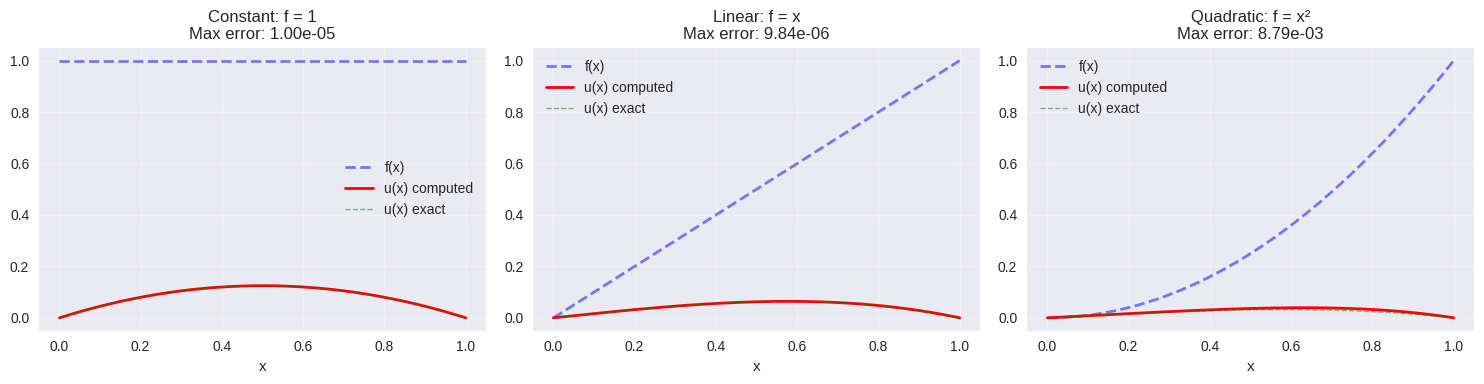

✓ Inverse Laplacian solves Poisson's equation accurately!


In [18]:
# Solve Poisson equation with various source terms
domain = IntervalDomain(0, 1)
L2 = Lebesgue(50, domain, basis='sine')
bc = BoundaryConditions(bc_type='dirichlet', left=0, right=0)
solver = InverseLaplacian(L2, bc, method='spectral', dofs=50)

source_terms = [
    {
        'name': 'Constant: f = 1',
        'source': lambda x: np.ones_like(x),
        'exact': lambda x: x * (1 - x) / 2
    },
    {
        'name': 'Linear: f = x',
        'source': lambda x: x,
        'exact': lambda x: x * (1 - x**2) / 6
    },
    {
        'name': 'Quadratic: f = x²',
        'source': lambda x: x**2,
        'exact': lambda x: x * (1 - x) * (1 + x) / 12
    }
]

x_plot = np.linspace(0, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, case in enumerate(source_terms):
    # Create source
    f = Function(L2, evaluate_callable=case['source'])

    # Solve
    u = solver(f)

    # Evaluate
    f_vals = f.evaluate(x_plot)
    u_vals = u.evaluate(x_plot)
    u_exact_vals = case['exact'](x_plot)

    # Compute error
    error = np.max(np.abs(u_vals - u_exact_vals))

    # Plot
    ax = axes[i]
    ax.plot(x_plot, f_vals, 'b--', linewidth=2, label='f(x)', alpha=0.5)
    ax.plot(x_plot, u_vals, 'r-', linewidth=2, label='u(x) computed')
    ax.plot(x_plot, u_exact_vals, 'g--', linewidth=1, label='u(x) exact', alpha=0.5)
    ax.set_xlabel('x')
    ax.set_title(f"{case['name']}\nMax error: {error:.2e}")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Inverse Laplacian solves Poisson's equation accurately!")

## 8. Summary and Best Practices

### Key Takeaways

1. **The Laplacian Operator**
   - Represents the second derivative: $-\Delta u = -d^2u/dx^2$
   - Self-adjoint with complete eigenfunction basis
   - Two implementations: spectral and finite difference

2. **Spectral Method**
   - Uses eigenfunction expansion
   - Exponentially accurate for smooth functions
   - Best for standard boundary conditions
   - Requires smooth functions

3. **Finite Difference Method**
   - Discretizes on a grid
   - Algebraically accurate (2nd or 4th order)
   - More flexible for complex problems
   - Works with less smooth functions

4. **Inverse Laplacian**
   - Solves Poisson's equation: $-\Delta u = f$
   - Fundamental for Gaussian random fields
   - Implemented via spectral or FEM methods
   - Provides covariance operator

5. **Eigenvalue Decomposition**
   - Access to eigenvalues: $\lambda_k = k^2$ (Dirichlet)
   - Access to eigenfunctions: $\phi_k(x) = \sqrt{2/L} \sin(k\pi x/L)$
   - Enables spectral analysis

### Best Practices

✅ **DO:**
- Use spectral methods for smooth problems with simple geometry
- Use FD methods for complex domains or less smooth functions
- Choose higher-order FD schemes for better accuracy
- Verify solutions against known test cases
- Check eigenvalue/eigenfunction properties

⚠️ **DON'T:**
- Use spectral methods on discontinuous functions
- Use too few grid points (FD) or modes (spectral)
- Ignore boundary conditions (they determine the eigenfunctions!)
- Mix incompatible boundary conditions and basis functions

### Method Selection Guide

| Criterion | Spectral | Finite Difference |
|-----------|----------|-------------------|
| **Smooth functions** | ✓✓✓ Excellent | ✓ Good |
| **Non-smooth functions** | ✗ Poor | ✓✓ Better |
| **Accuracy** | Exponential | Algebraic (2nd/4th order) |
| **Flexibility** | Standard BCs | Any BCs |
| **Computational cost** | Low (FFT) | Moderate (sparse matrix) |
| **Implementation** | Complex | Simple |

### Next Steps

- Explore **Sobolev spaces** using the Laplacian spectrum
- Study **spectral methods** for PDEs
- Learn about **Gaussian random fields** via inverse Laplacian
- Investigate **boundary value problems** and Green's functions